# Inspecting GWs `BilBY` runs

In this notebook, we analyse the distance posteriors produced by GWs simulations. We have two set of detectors: LVK (current) and CE (future), and generate events (NSBH mergers, with $q=1/10$, and $M_{\rm NS} = 1.48 M_\odot$) at the relevant redshifts so that they are observable (SNR, $\rho > 8$).

The main aim is to get a realistic estimate of how the uncertainties in $d_L$ (the luminosity distance) change with redshift, and use this estimate when simulating realistic sources for the FRB-GWs associations.

**Load modules**

In [36]:
import numpy as np

import scipy.interpolate as sip
from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

## Random numbers
from numpy.random import default_rng
rng_seed = 1234
rng = default_rng(seed=rng_seed)


## Plotting
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [38]:
SAVE_FIG = True

-----------------------------------------------------------

**Loading the samples**

These are the $d_L$ posterior samples, produced by parameter estimation of each simulated event. In other words, it is PDF of the distance estimate for each event.

In [3]:
DL_samples = np.load('../../Data/GWs_data/dL_samples.npz')
print(DL_samples.files)

['LVK_z005', 'LVK_z01', 'LVK_z02', 'CE_z005', 'CE_z01', 'CE_z02', 'CE_z05', 'CE_z075', 'CE_z1', 'CE_z15', 'CE_z2', 'CE_z02_BBH']


The names correspond to the detector (`LVK`, `CE`) and to the redshifts `{0.05, 0.1, 0.2, 0.5, 0.75, 1.0, 1.5, 2.0}`. All of them are NSBH, with one test case of a BBH with CE at redshift $z=0.2$.

In [4]:
dist_names = DL_samples.files[:-1]
dist_names

['LVK_z005',
 'LVK_z01',
 'LVK_z02',
 'CE_z005',
 'CE_z01',
 'CE_z02',
 'CE_z05',
 'CE_z075',
 'CE_z1',
 'CE_z15',
 'CE_z2']

In [5]:
dist_names[:3]

['LVK_z005', 'LVK_z01', 'LVK_z02']

In [6]:
# Redshift range for each detector
z_LVK_range = [0.05, 0.1, 0.2]
z_CE_range = [0.05, 0.1, 0.2, 0.5, 0.75, 1.0, 1.5, 2.0]

-------------------------------------

**Useful functions**

In [7]:
def renormalise_dist_posterior(sample_name, N_draw, alpha=-2):
    dist_samples = DL_samples[sample_name]

    # Re-weight weights
    # We are doing this procedure to remove the prior used in the parameter estimation
    p_values = (dist_samples**alpha)/np.sum(dist_samples**alpha)

    # Choose distance samples indices, based on weights
    indices_all = np.arange(0, len(dist_samples))
    indices_selected = rng.choice(indices_all, size=N_draw, replace=True, p=p_values)
    
    ## The normalised samples
    DL_normed = dist_samples[indices_selected]
    
    # # Calculate kde
    kde_normed = gaussian_kde(DL_normed)

    return DL_normed, kde_normed

In [8]:
def quantile_range(array, q_min, q_max):
    value_min = np.quantile(array, q_min)
    value_max = np.quantile(array, q_max)
    
    return value_max-value_min

In [9]:
## Create the fitting function
def func_quad(x, a0, a1, a2):
    return a0 + a1*x + a2*x**2

def func_lin(x, a0, a1):
    return a0+a1*x

-------------------------

## LVK samples analysis

As said in the introduction, here we are going to use the LVK $d_L$ samples, to get an estimate of how the distance errors scale with redshift for current detectors. Since the posteriors are not perfect Gaussian, we are using two statistics to estimate their uncertainty/range: the classic, *standard deviation* and the *quantile range* covering $\sim 68 \%$ probability.

In [10]:
## Drawing and renormalising samples

N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[:3]

dL_array_LVK = np.zeros((len(data_files), N_draw_samples))
dL_kdes_LVK = np.zeros((len(data_files), dL_res))

dL_range_LVK = np.linspace(0, 2500, dL_res)

for idx, name in enumerate(data_files):
    dL_array_LVK[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes_LVK[idx, :] = dL_kde(dL_range_LVK)

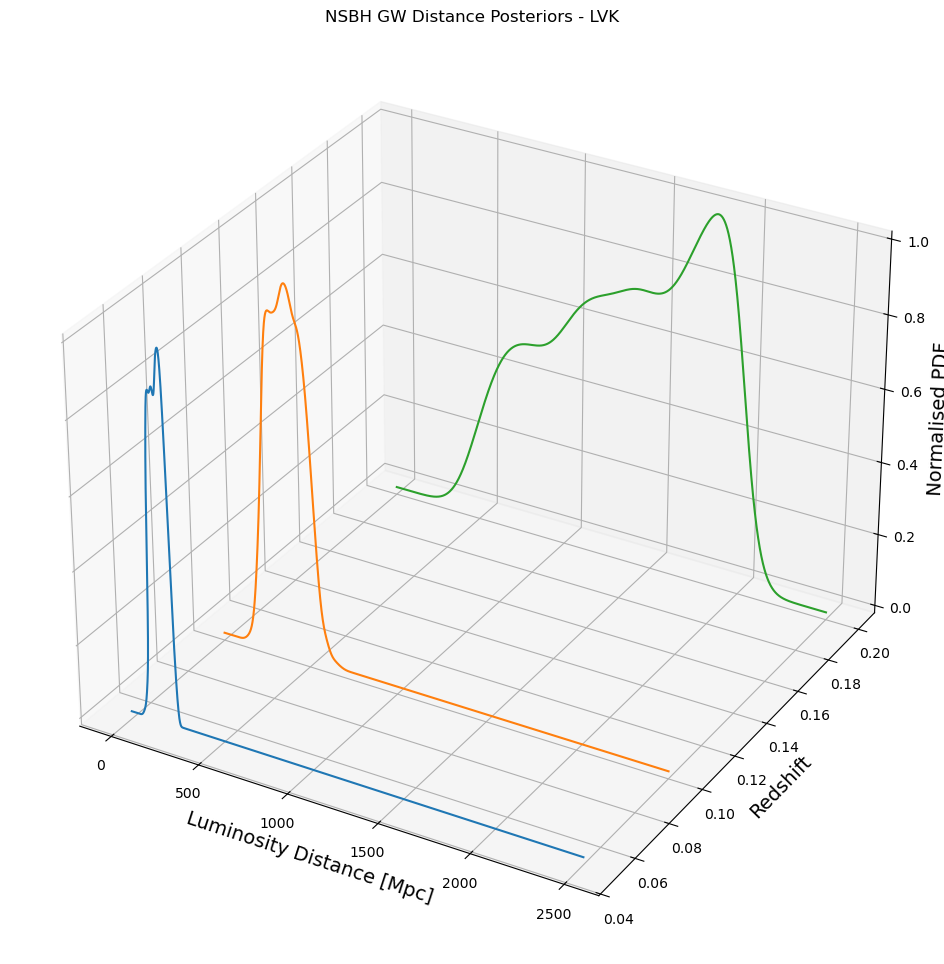

In [12]:
fig = plt.figure(figsize = (14, 12))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - LVK')

for idx_z, z_val in enumerate(z_LVK_range):
    ax.plot(dL_range_LVK, np.repeat(z_val, repeats=len(dL_range_LVK)), dL_kdes_LVK[idx_z, :]/np.max(dL_kdes_LVK[idx_z, :]))

ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised PDF', fontsize=14)

plt.show()

In [13]:
dL_error_LVK = np.zeros(3)  # based on std
dL_qerror_LVK = np.zeros(3)  # based on quantile range

for i in range(3):
    dL_error_LVK[i] = np.std(dL_array_LVK[i, :])/np.median(dL_array_LVK[i, :])*100
    dL_qerror_LVK[i] = quantile_range(dL_array_LVK[i, :], 0.158, 0.842)/2/np.median(dL_array_LVK[i, :])*100
    print("std based error: ", dL_error_LVK[i], "and quantile based error: ", dL_qerror_LVK[i])

std based error:  21.080697785198765 and quantile based error:  23.499674001767985
std based error:  24.94640089382876 and quantile based error:  27.35063529307312
std based error:  31.18611960916399 and quantile based error:  36.528753855103815


**Note**: The `std` and `quantile` based errors are a bit different, as expected, but the difference is not that big (for our purposes).

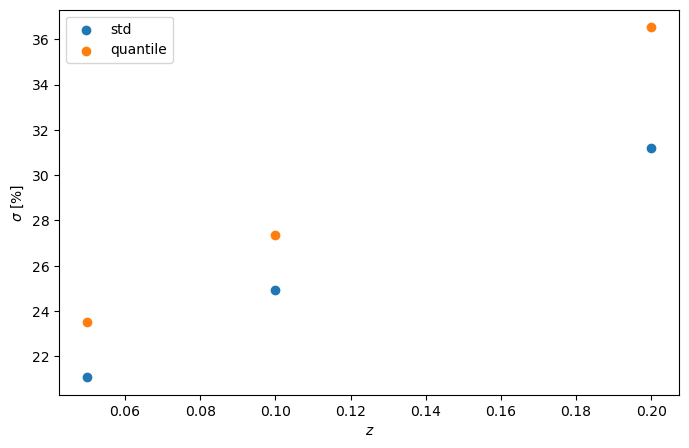

In [14]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, label='std')
ax1.scatter(z_LVK_range, dL_qerror_LVK, label='quantile')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Fit based on Standard deviations**

We interpolate the error estimates in the whole redshift range of interest. For all cases, we use a **linear** and a **quadratic** fit.

In [15]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_error_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [16]:
popt_LVK_std, _ = curve_fit(func_quad, z_LVK_range, dL_error_LVK)
popt_lin_LVK_std, _ = curve_fit(func_lin, z_LVK_range, dL_error_LVK)

C:\Users\klera\AppData\Local\Temp\ipykernel_1364\311887045.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK_std, _ = curve_fit(func_quad, z_LVK_range, dL_error_LVK)


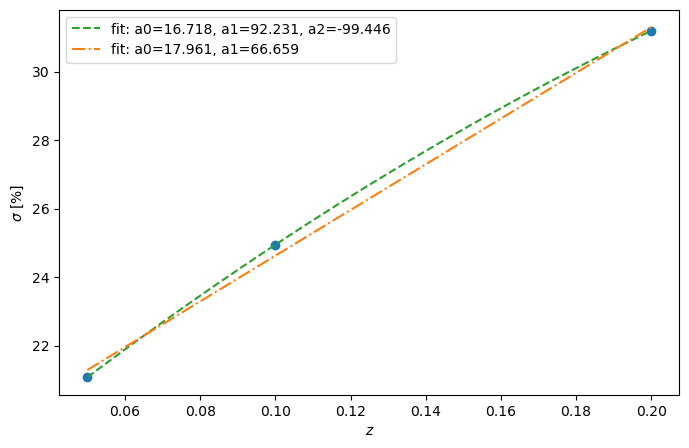

In [17]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK_std), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_LVK_std))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK_std), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK_std))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Quantiles**

In [18]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_qerror_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [19]:
popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_qerror_LVK)
popt_lin_LVK, _ = curve_fit(func_lin, z_LVK_range, dL_qerror_LVK)

C:\Users\klera\AppData\Local\Temp\ipykernel_1364\2870876851.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_qerror_LVK)


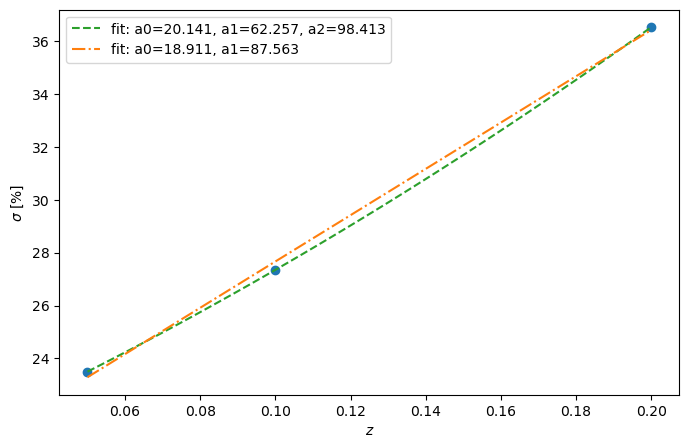

In [21]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_qerror_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_LVK))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

## CE samples analysis

Same as above, but for the CE samples.

In [22]:
N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[3:]

dL_array_CE = np.zeros((len(data_files), N_draw_samples))
dL_kdes_CE = np.zeros((len(data_files), dL_res))

dL_range_CE = np.linspace(0, 20000, dL_res)

for idx, name in enumerate(data_files):
    dL_array_CE[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes_CE[idx, :] = dL_kde(dL_range_CE)

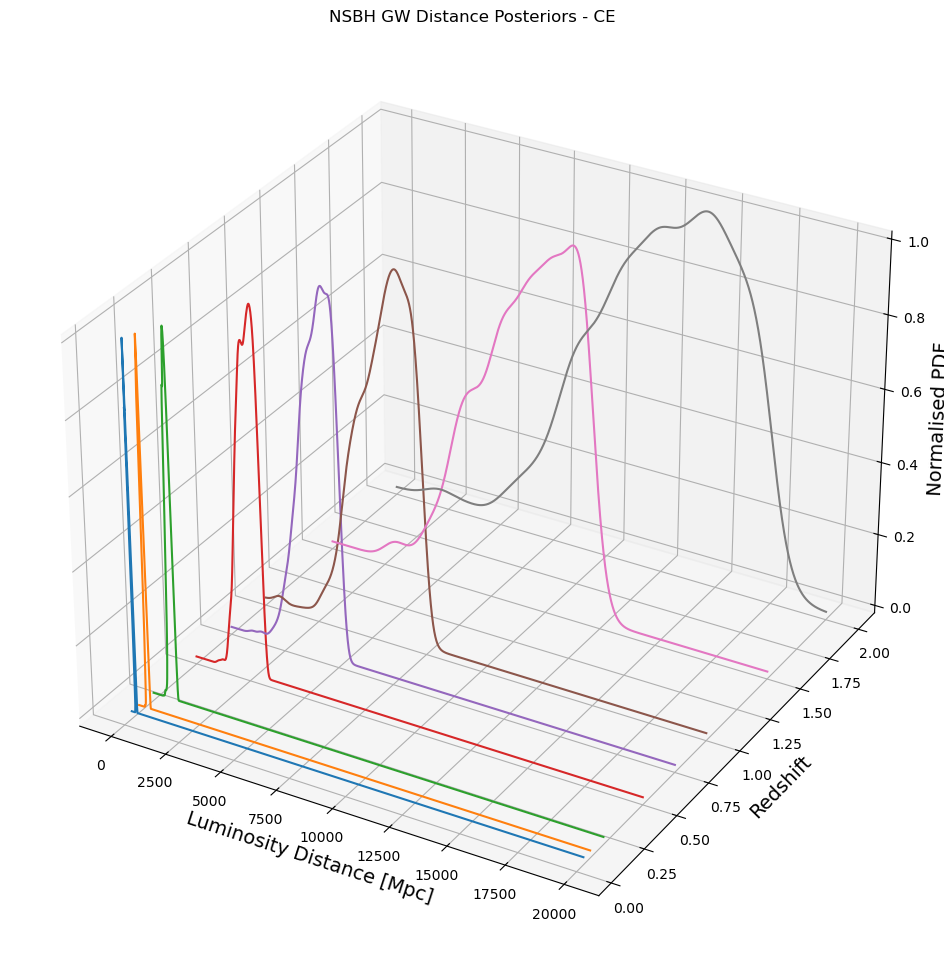

In [23]:
fig = plt.figure(figsize = (14, 12))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - CE')

for idx_z, z_val in enumerate(z_CE_range):
    ax.plot(dL_range_CE, np.repeat(z_val, repeats=len(dL_range_CE)), dL_kdes_CE[idx_z, :]/np.max(dL_kdes_CE[idx_z, :]))

ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised PDF', fontsize=14)

plt.show()

In [25]:
dL_error_CE = np.zeros(8)
dL_qerror_CE = np.zeros(8)

for i in range(8):
    dL_error_CE[i] = np.std(dL_array_CE[i, :])/np.median(dL_array_CE[i, :])*100
    dL_qerror_CE[i] = quantile_range(dL_array_CE[i, :], 0.158, 0.842)/2/np.median(dL_array_CE[i, :])*100    
    print("std based error: ", dL_error_CE[i], "and quantile based error: ", dL_qerror_CE[i])

std based error:  6.884551930473752 and quantile based error:  7.0593086407798475
std based error:  8.970880987345243 and quantile based error:  9.482566354553983
std based error:  11.014296919099076 and quantile based error:  11.480279057540208
std based error:  15.917773204067656 and quantile based error:  17.15138028080002
std based error:  17.69109264839027 and quantile based error:  18.275633435729166
std based error:  20.28710174828225 and quantile based error:  21.781673656700754
std based error:  22.688139861303828 and quantile based error:  24.924001088457796
std based error:  24.120612544618428 and quantile based error:  26.089591374320037


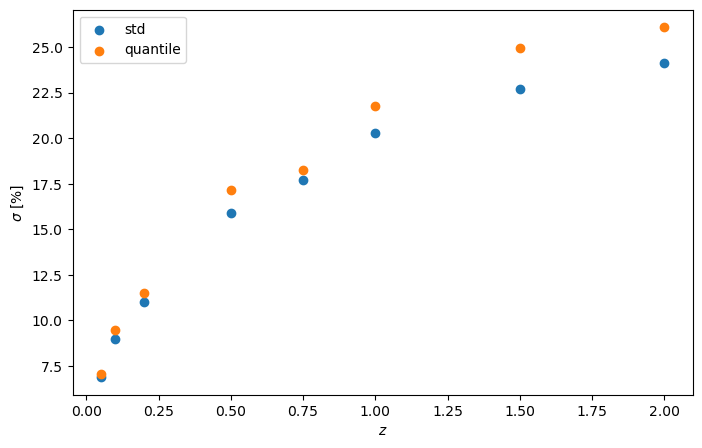

In [26]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE, label='std')
ax1.scatter(z_CE_range, dL_qerror_CE, label='quantile')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Standard deviations**

In [27]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_error_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [28]:
popt_CE_std, _ = curve_fit(func_quad, z_CE_range, dL_error_CE)
popt_lin_CE_std, _ = curve_fit(func_lin, z_CE_range, dL_error_CE)

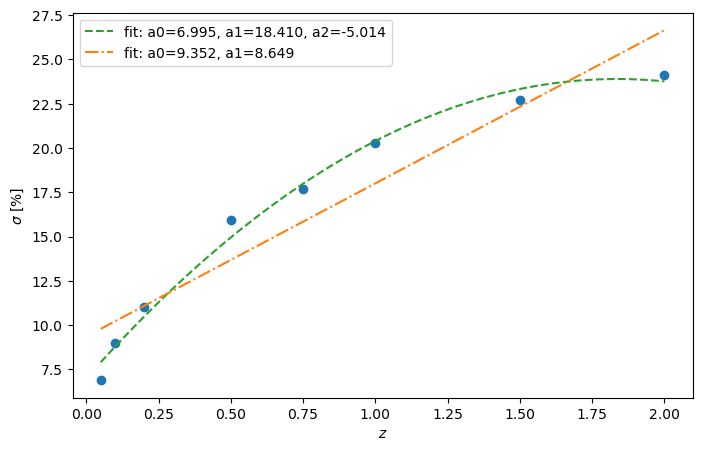

In [30]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE_std), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_CE_std))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE_std), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE_std))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Quantiles**

In [31]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_qerror_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [32]:
popt_CE, pcov_CE = curve_fit(func_quad, z_CE_range, dL_qerror_CE)
popt_lin_CE, pcov_CE = curve_fit(func_lin, z_CE_range, dL_qerror_CE)

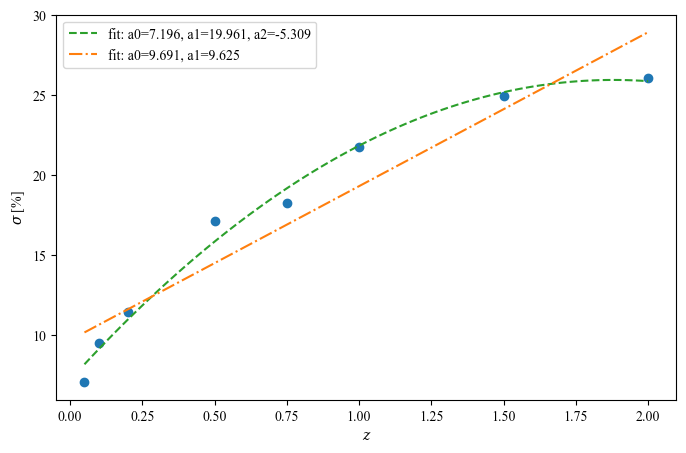

In [93]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_qerror_CE)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_CE))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

------------------------

## Comparison between LVK and CE results

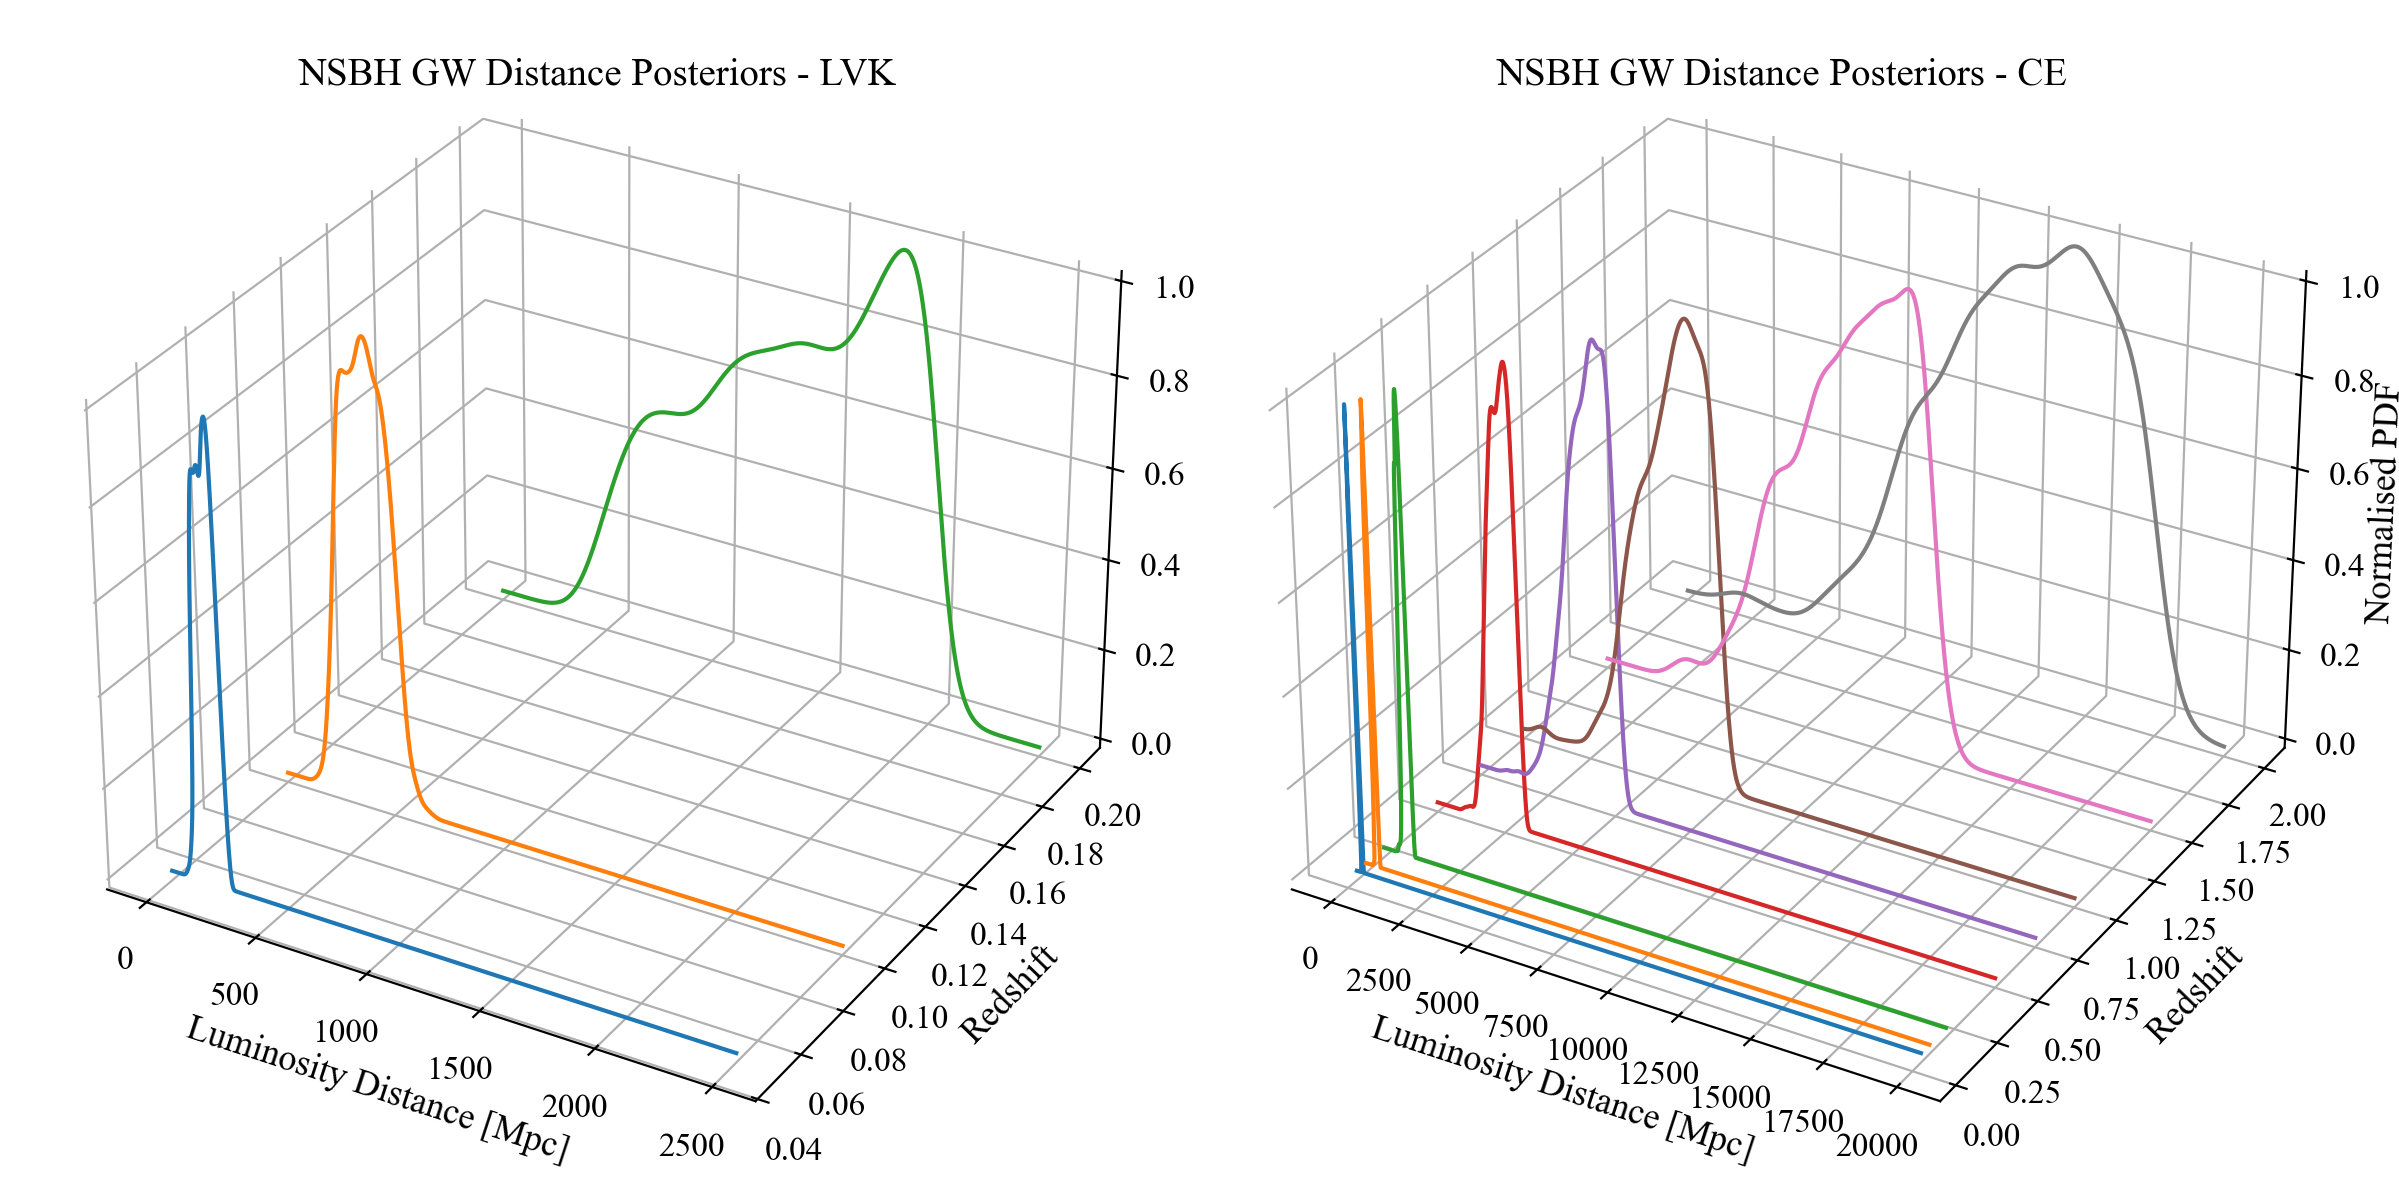

In [173]:
fig = plt.figure(figsize = (12, 12), dpi=200)
ax1 = fig.add_subplot(121, projection = '3d')
ax2 = fig.add_subplot(122, projection = '3d')

ax1.set_title('NSBH GW Distance Posteriors - LVK', y=1.01, fontsize=14)

for idx_z, z_val in enumerate(z_LVK_range):
    ax1.plot(dL_range_LVK, np.repeat(z_val, repeats=len(dL_range_LVK)), dL_kdes_LVK[idx_z, :]/np.max(dL_kdes_LVK[idx_z, :]))

ax1.set_xlabel('Luminosity Distance [Mpc]', fontsize=13)
ax1.set_ylabel('Redshift', fontsize=13)
# ax1.set_zlabel('Normalised PDF', fontsize=14)

# Get rid of the panes
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.tick_params(axis='both', which='major', labelsize=12)

ax2.set_title('NSBH GW Distance Posteriors - CE', y=1.01, fontsize=14)

for idx_z, z_val in enumerate(z_CE_range):
    ax2.plot(dL_range_CE, np.repeat(z_val, repeats=len(dL_range_CE)), dL_kdes_CE[idx_z, :]/np.max(dL_kdes_CE[idx_z, :]))

ax2.set_xlabel('Luminosity Distance [Mpc]', fontsize=13)
ax2.set_ylabel('Redshift', fontsize=13)
ax2.set_zlabel('Normalised PDF', labelpad=-0.9, fontsize=13)

# Get rid of the panes
ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax2.tick_params(axis='both', which='major', labelsize=12)

# ax2.set_box_aspect(None, zoom=0.9)

plt.tight_layout(pad=1.1)


if SAVE_FIG:
    plt.savefig("figures/DL_posteriors_LVK_CE.png", dpi=250, bbox_inches='tight')

# fig.get_layout_engine().set(w_pad=0.0, h_pad=0.0, hspace=10.5,
#                             wspace=0.05)

plt.show()
plt.close()

ValueError: x and y must be the same size

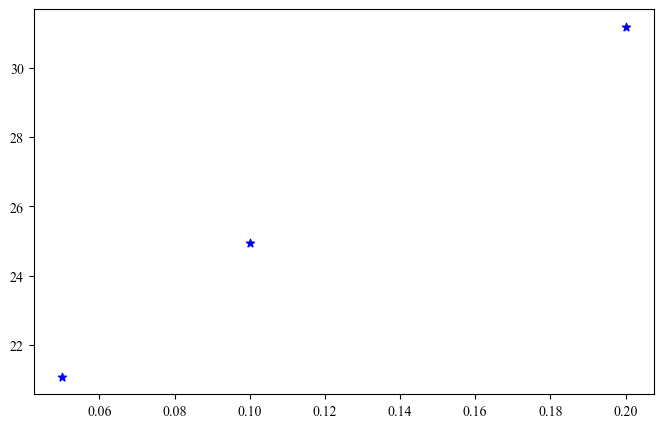

In [90]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, marker='*', c='blue', label='LVK (std)')
ax1.scatter(z_LVK_range, dL_range_LVK, marker='*', facecolors='none', edgecolors='blue', label='LVK (quantile)')
ax1.scatter(z_CE_range, dL_error_CE, c='r', label='CE (std)')
ax1.scatter(z_CE_range, dL_range_CE, marker='*', facecolors='none', edgecolors='red', label='CE (quantile)')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

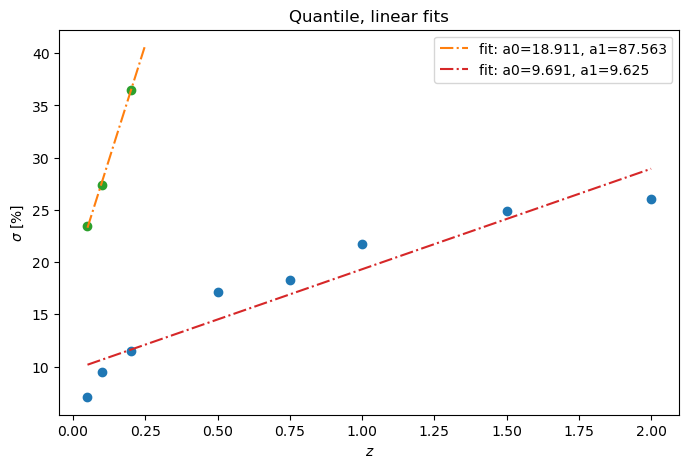

In [31]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_range_LVK, c='tab:green')
plt.plot(z_detailed[z_detailed<0.25], func_lin(z_detailed[z_detailed<0.25], *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK))

ax1.scatter(z_CE_range, dL_range_CE, c='tab:blue')
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:red', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()
ax1.set_title('Quantile, linear fits')

plt.show()

----------------------------

**Saving the linear interpolations**

Note that we are saving: $\sigma_{d_L}/d_L \times 100$. This is important, when we want to use the interpolation in the main code.

In [32]:
np.savez('quantile_linear_interpolations.npz', LVK_interpolation = popt_lin_LVK, CE_interpolation = popt_lin_CE)

----------------------------------------------------

## 2D interpolation

In [29]:
from scipy.interpolate import RegularGridInterpolator

**LVK interpolation**

In [136]:
## Drawing and renormalising samples

N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[:3]

dL_array = np.zeros((len(data_files), N_draw_samples))
dL_kdes = np.zeros((len(data_files), dL_res))

dL_range = np.linspace(0, 2500, dL_res)

for idx, name in enumerate(data_files):
    dL_array[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes[idx, :] = dL_kde(dL_range)

In [137]:
N_points = 50
Step_size = dL_res//N_points

dL_points = np.zeros((len(data_files), N_points))

for idx, name in enumerate(data_files):
    dL_points[idx, :] = dL_kdes[idx, ::Step_size]

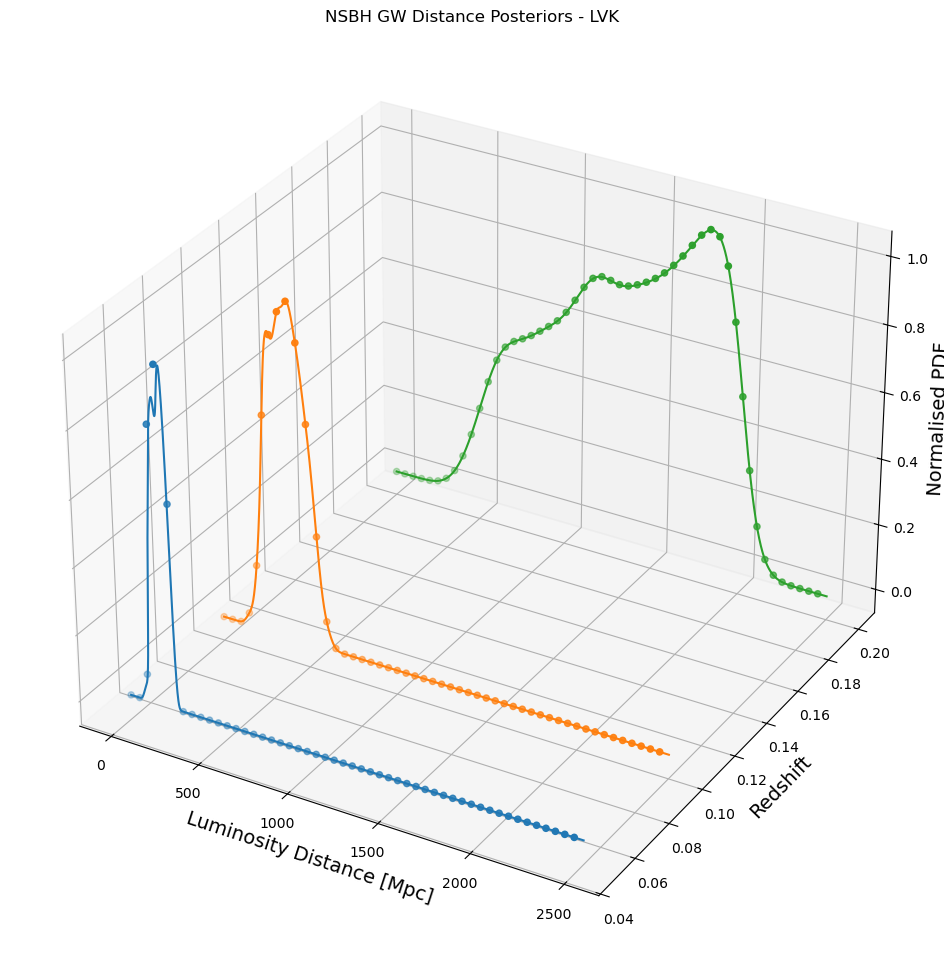

In [138]:
fig = plt.figure(figsize = (14, 12))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - LVK')

ax.plot(dL_range, np.repeat(0.05, repeats=len(dL_range)), dL_kdes[0, :]/np.max(dL_kdes[0, :]))
ax.plot(dL_range, np.repeat(0.1, repeats=len(dL_range)), dL_kdes[1, :]/np.max(dL_kdes[1, :]))
ax.plot(dL_range, np.repeat(0.2, repeats=len(dL_range)), dL_kdes[2, :]/np.max(dL_kdes[2, :]))

ax.scatter(dL_range[::Step_size], np.repeat(0.05, repeats=len(dL_range[::Step_size])),\
           dL_points[0,:]/np.max(dL_points[0,:]))
ax.scatter(dL_range[::Step_size], np.repeat(0.1, repeats=len(dL_range[::Step_size])),\
           dL_points[1,:]/np.max(dL_points[1,:]))
ax.scatter(dL_range[::Step_size], np.repeat(0.2, repeats=len(dL_range[::Step_size])),\
           dL_points[2,:]/np.max(dL_points[2,:]))

ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised PDF', fontsize=14)

plt.show()

In [139]:
x, y = dL_range[::Step_size], z_LVK_range

In [140]:
dL_points_norm = dL_points/(np.max(dL_points, axis=1).reshape(len(z_LVK_range), 1))

In [141]:
interp = RegularGridInterpolator((x, y), dL_points_norm.T,
                                 bounds_error=False, method='linear', fill_value=None)

In [142]:
xx = dL_range
yy = np.linspace(np.min(z_LVK_range), np.max(z_LVK_range), 10)
X, Y = np.meshgrid(xx, yy, indexing='ij')

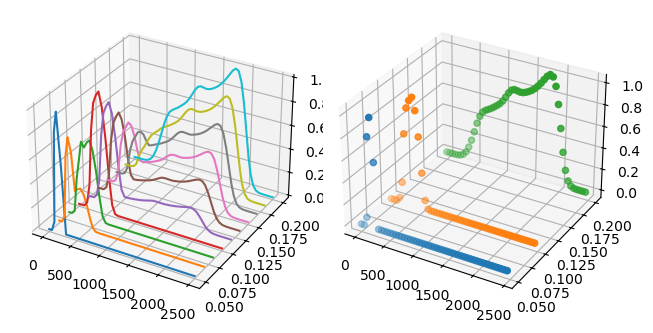

In [143]:
fig = plt.figure()

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# ax.scatter(xg.ravel(), yg.ravel(), data.ravel(),
#            s=60, c='k', label='data')

for idx, z_yy in enumerate(yy):
    ax1.plot(dL_range, np.repeat(z_yy, repeats=len(dL_range)), interp((X, Y))[:, idx])

for idx, z_LVK in enumerate(z_LVK_range):
    ax2.scatter(dL_range[::Step_size], np.repeat(z_LVK, repeats=len(dL_range[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))

# # ground truth
# ax.plot_wireframe(X, Y, ff(X, Y), rstride=3, cstride=3,
#                   alpha=0.4, label='ground truth')
# plt.legend()
plt.tight_layout()
plt.show()

**CE interpolation**

In [71]:
N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[3:]

dL_array = np.zeros((len(data_files), N_draw_samples))
dL_kdes = np.zeros((len(data_files), dL_res))

dL_range = np.linspace(0, 20000, dL_res)

for idx, name in enumerate(data_files):
    dL_array[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes[idx, :] = dL_kde(dL_range)

In [127]:
N_points = 500
Step_size = dL_res//N_points

dL_points = np.zeros((len(data_files), N_points))

for idx, name in enumerate(data_files):
    dL_points[idx, :] = dL_kdes[idx, ::Step_size]

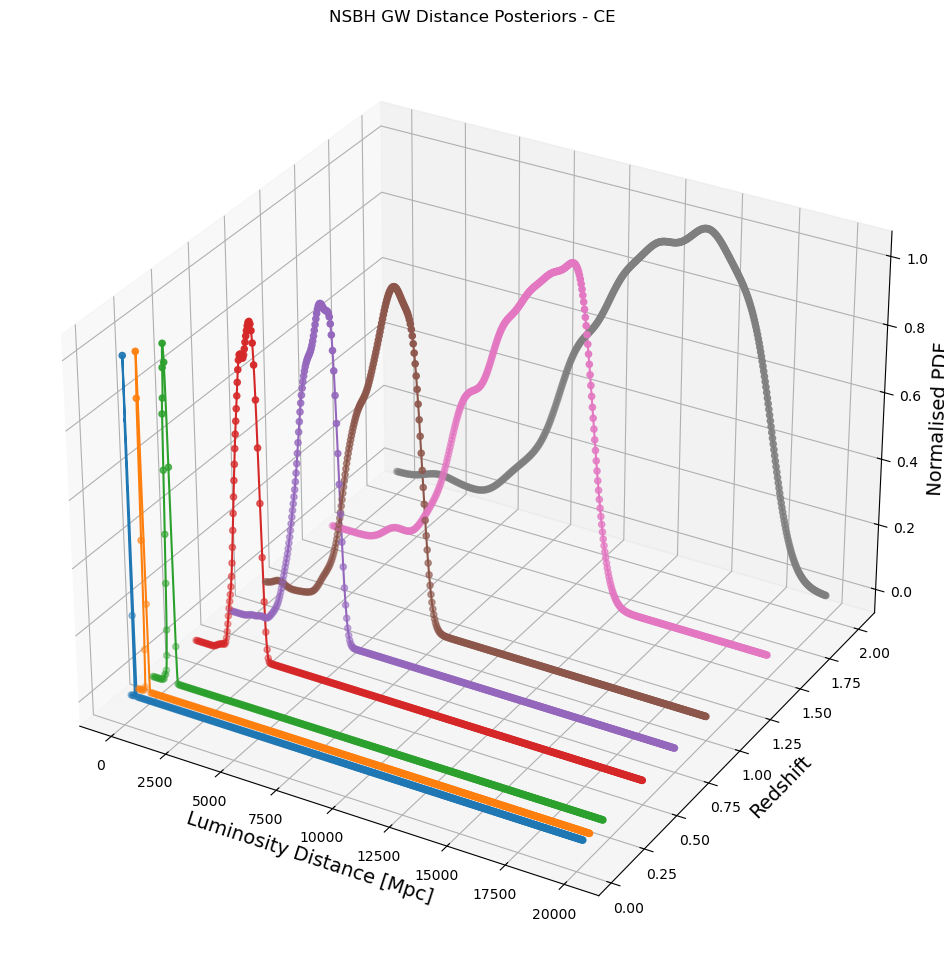

In [128]:
fig = plt.figure(figsize = (14, 12))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - CE')

ax.plot(dL_range, np.repeat(0.05, repeats=len(dL_range)), dL_kdes[0, :]/np.max(dL_kdes[0, :]))
ax.plot(dL_range, np.repeat(0.1, repeats=len(dL_range)), dL_kdes[1, :]/np.max(dL_kdes[1, :]))
ax.plot(dL_range, np.repeat(0.2, repeats=len(dL_range)), dL_kdes[2, :]/np.max(dL_kdes[2, :]))
ax.plot(dL_range, np.repeat(0.5, repeats=len(dL_range)), dL_kdes[3, :]/np.max(dL_kdes[3, :]))
ax.plot(dL_range, np.repeat(0.75, repeats=len(dL_range)), dL_kdes[4, :]/np.max(dL_kdes[4, :]))
ax.plot(dL_range, np.repeat(1.0, repeats=len(dL_range)), dL_kdes[5, :]/np.max(dL_kdes[5, :]))
ax.plot(dL_range, np.repeat(1.5, repeats=len(dL_range)), dL_kdes[6, :]/np.max(dL_kdes[6, :]))
ax.plot(dL_range, np.repeat(2.0, repeats=len(dL_range)), dL_kdes[7, :]/np.max(dL_kdes[7, :]))


for idx, z_CE in enumerate(z_CE_range):
    ax.scatter(dL_range[::Step_size], np.repeat(z_CE, repeats=len(dL_range[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))

ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised PDF', fontsize=14)

plt.show()

In [129]:
x, y = dL_range[::Step_size], z_CE_range

In [130]:
dL_points_norm = dL_points/(np.max(dL_points, axis=1).reshape(len(z_CE_range), 1))

In [131]:
interp = RegularGridInterpolator((x, y), dL_points_norm.T,
                                 bounds_error=False, method='linear', fill_value=None)

In [132]:
xx = dL_range
yy = np.linspace(np.min(z_CE_range), np.max(z_CE_range), 10)
# yy = np.copy(z_CE_range)
X, Y = np.meshgrid(xx, yy, indexing='ij')

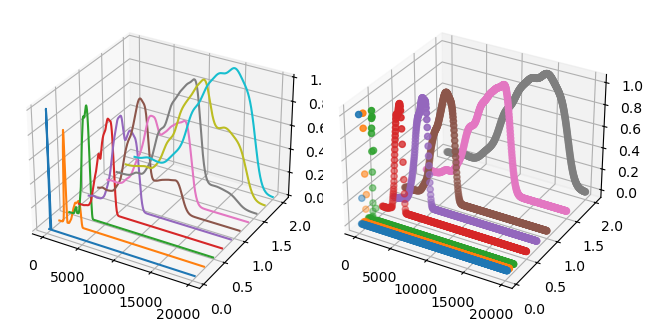

In [135]:
fig = plt.figure()

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# ax.scatter(xg.ravel(), yg.ravel(), data.ravel(),
#            s=60, c='k', label='data')

for idx, z_yy in enumerate(yy):
    ax1.plot(dL_range, np.repeat(z_yy, repeats=len(dL_range)), interp((X, Y))[:, idx])

for idx, z_CE in enumerate(z_CE_range):
    ax2.scatter(dL_range[::Step_size], np.repeat(z_CE, repeats=len(dL_range[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))

# # ground truth
# ax.plot_wireframe(X, Y, ff(X, Y), rstride=3, cstride=3,
#                   alpha=0.4, label='ground truth')
# plt.legend()
plt.tight_layout()
plt.show()